In [6]:
import matplotlib as plt
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd

In [4]:
file_pt = "../data/processed/updated-punjab.csv"
df = pd.read_csv(file_pt)
print(df.head())

   year    month  month_num  epi_week district  cases  deaths   T2M_mean  \
0  2018  January          1         1   attock      2       0  11.360000   
1  2019  January          1         1   attock      2       0   9.414286   
2  2020  January          1         1   attock      2       0   9.625714   
3  2016  January          1         2   attock      2       0  12.811429   
4  2017  January          1         2   attock      2       0   7.932857   

   RH2M_mean  PRECTOTCORR_sum  ...  month_sin  month_cos  week_sin  week_cos  \
0  39.900000             0.61  ...        0.5   0.866025  0.120537  0.992709   
1  61.732857            33.04  ...        0.5   0.866025  0.120537  0.992709   
2  57.798571             2.23  ...        0.5   0.866025  0.120537  0.992709   
3  50.505714             1.98  ...        0.5   0.866025  0.239316  0.970942   
4  44.685714             5.13  ...        0.5   0.866025  0.239316  0.970942   

   t1_cases  t2_cases   T2m_lag1  PRECTOTCORR_lag1  PRECTOTCOR

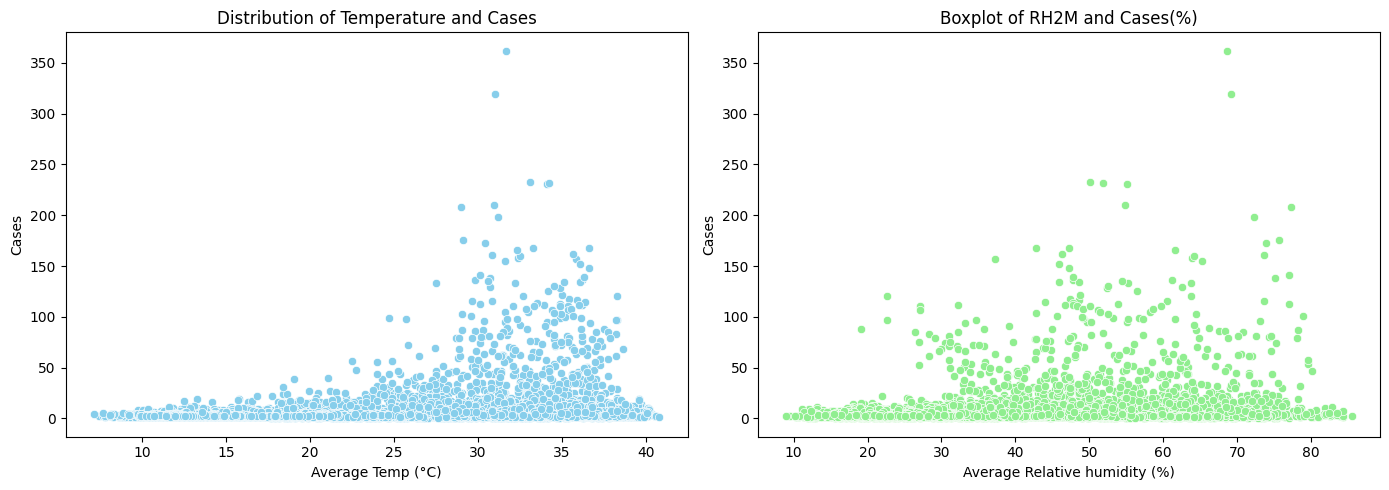

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram to check distribution and skewness
sns.scatterplot(x=df['T2M_mean'], y=df['cases'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Temperature and Cases')
axes[0].set_xlabel('Average Temp (°C)')
axes[0].set_ylabel('Cases')

# Boxplot to identify outliers
sns.scatterplot(x=df['RH2M_mean'], y=df['cases'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of RH2M and Cases(%)')
axes[1].set_xlabel('Average Relative humidity (%)')
axes[1].set_ylabel('Cases')
plt.tight_layout()
plt.show()

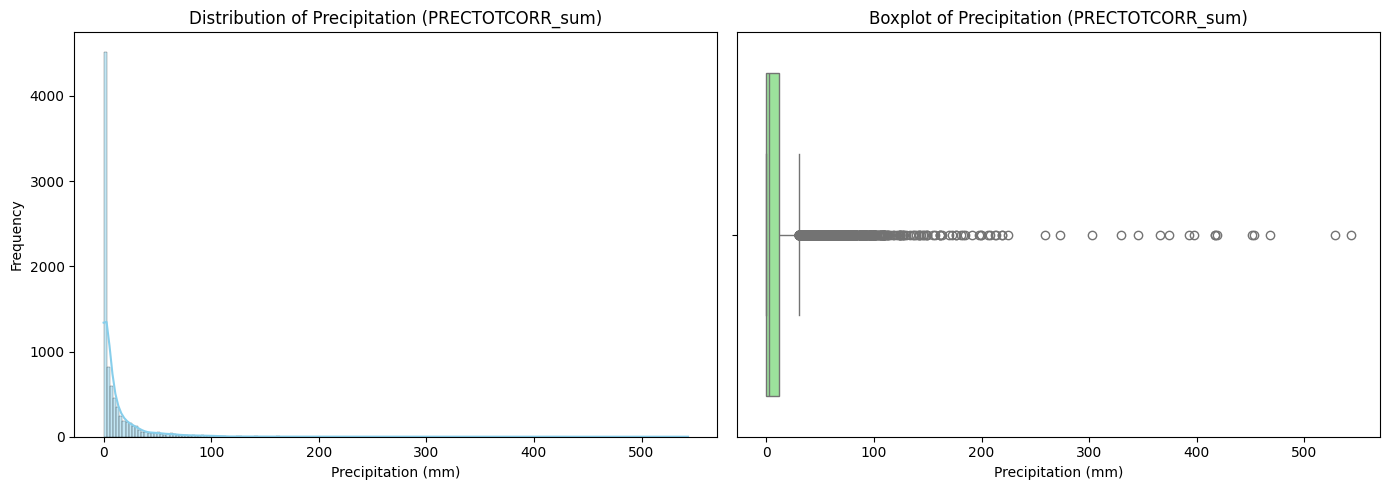

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram for PRECTOTCORR_sum
sns.histplot(df['PRECTOTCORR_sum'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Precipitation (PRECTOTCORR_sum)')
axes[0].set_xlabel('Precipitation (mm)')
axes[0].set_ylabel('Frequency')

# Boxplot for PRECTOTCORR_sum (optional, side by side)
sns.boxplot(x=df['PRECTOTCORR_sum'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Precipitation (PRECTOTCORR_sum)')
axes[1].set_xlabel('Precipitation (mm)')

plt.tight_layout()
plt.show()

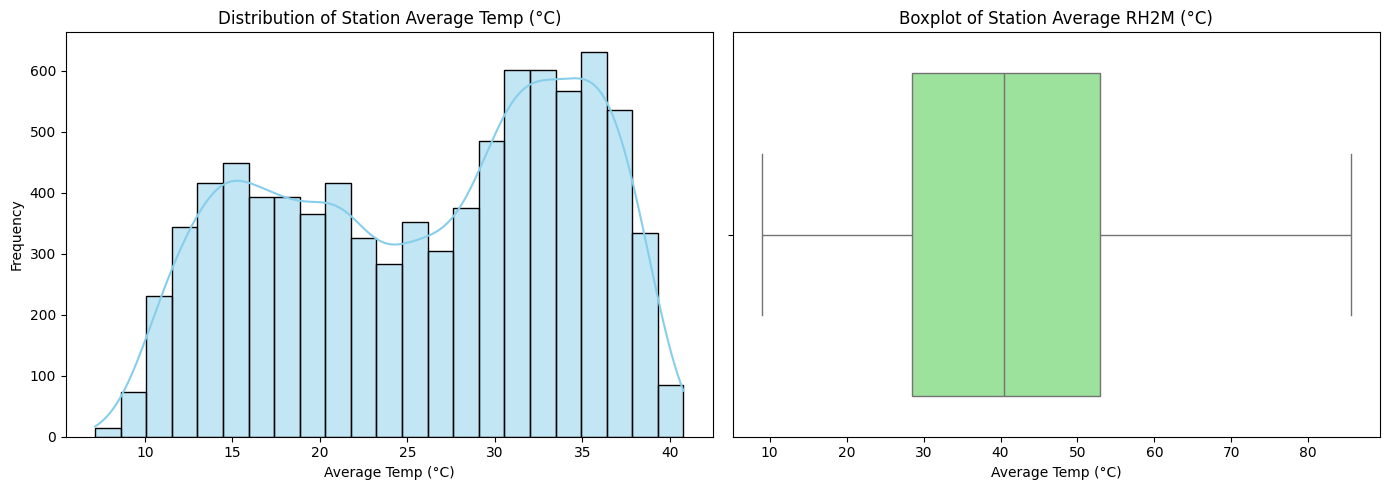

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram to check distribution and skewness
sns.histplot(df['T2M_mean'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Station Average Temp (°C)')
axes[0].set_xlabel('Average Temp (°C)')
axes[0].set_ylabel('Frequency')

# Boxplot to identify outliers
sns.boxplot(x=df['RH2M_mean'], ax=axes[1], color='lightgreen')
axes[1].set_title('Boxplot of Station Average RH2M (°C)')
axes[1].set_xlabel('Average Temp (°C)')

plt.tight_layout()
plt.show()

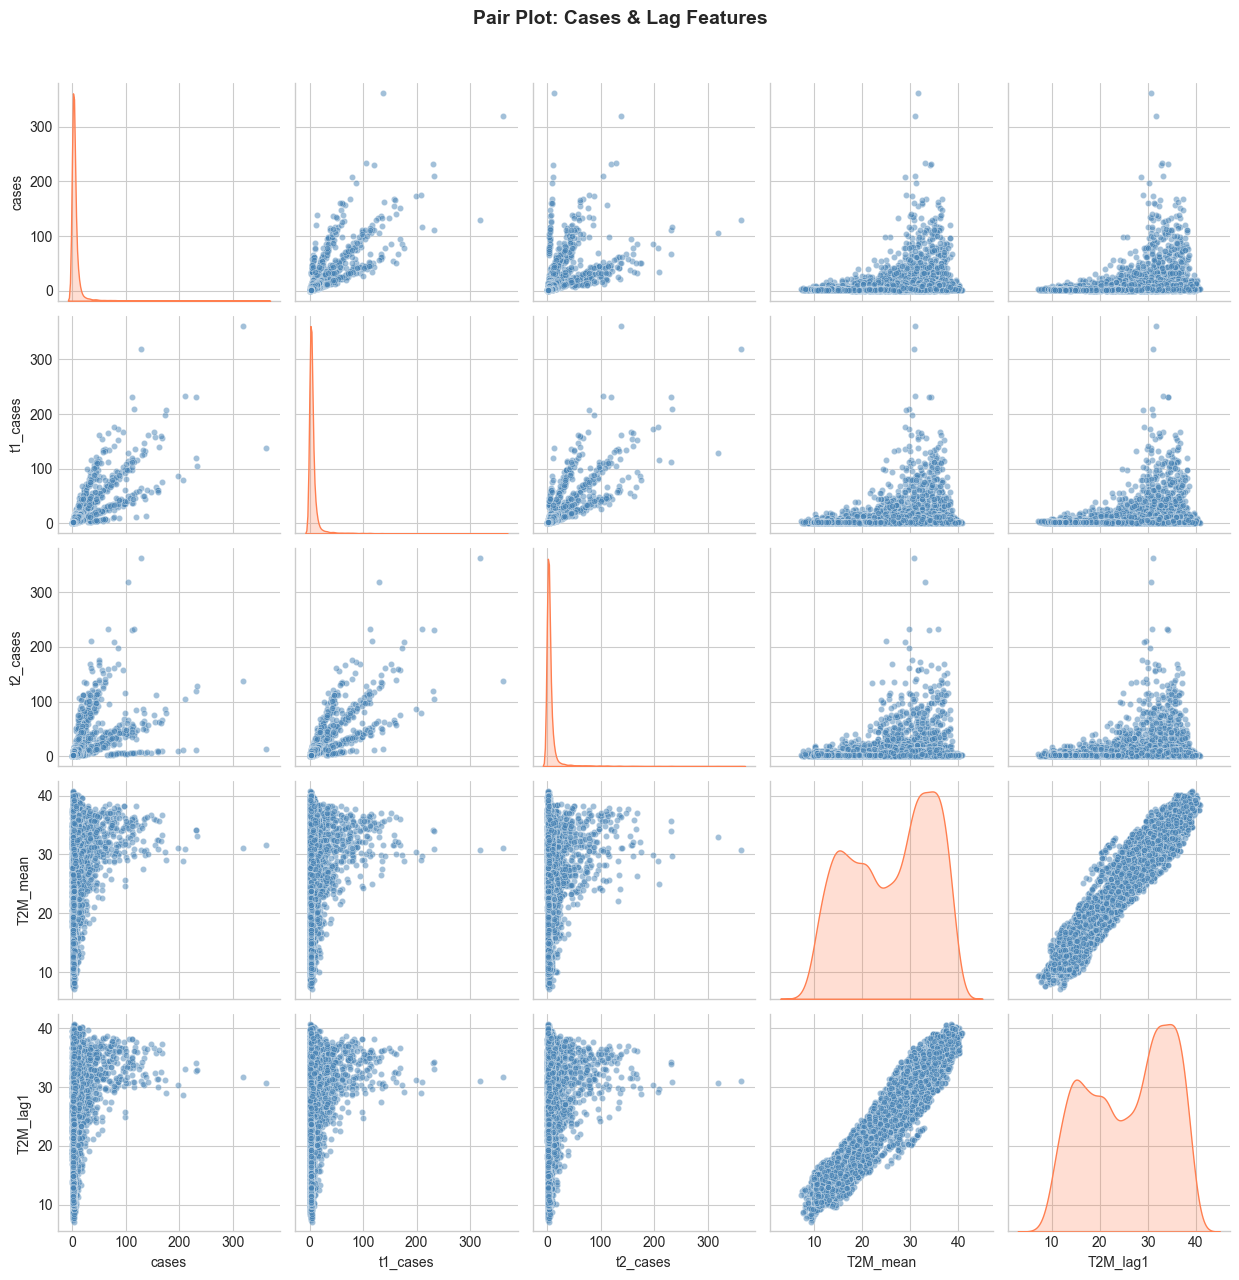

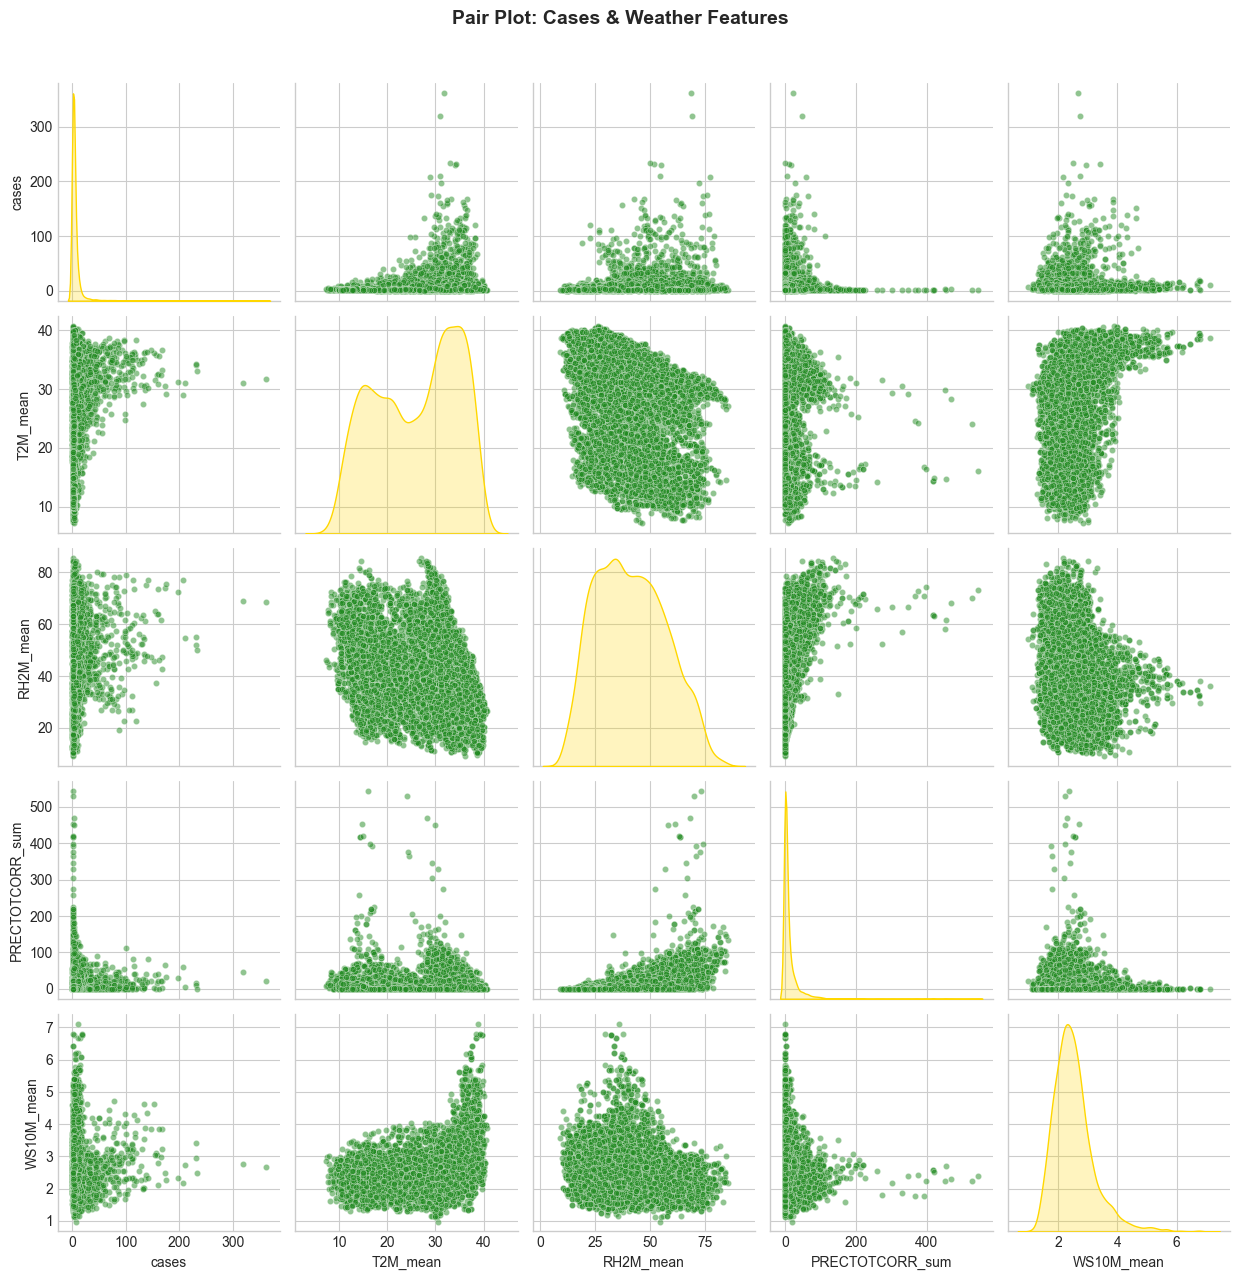

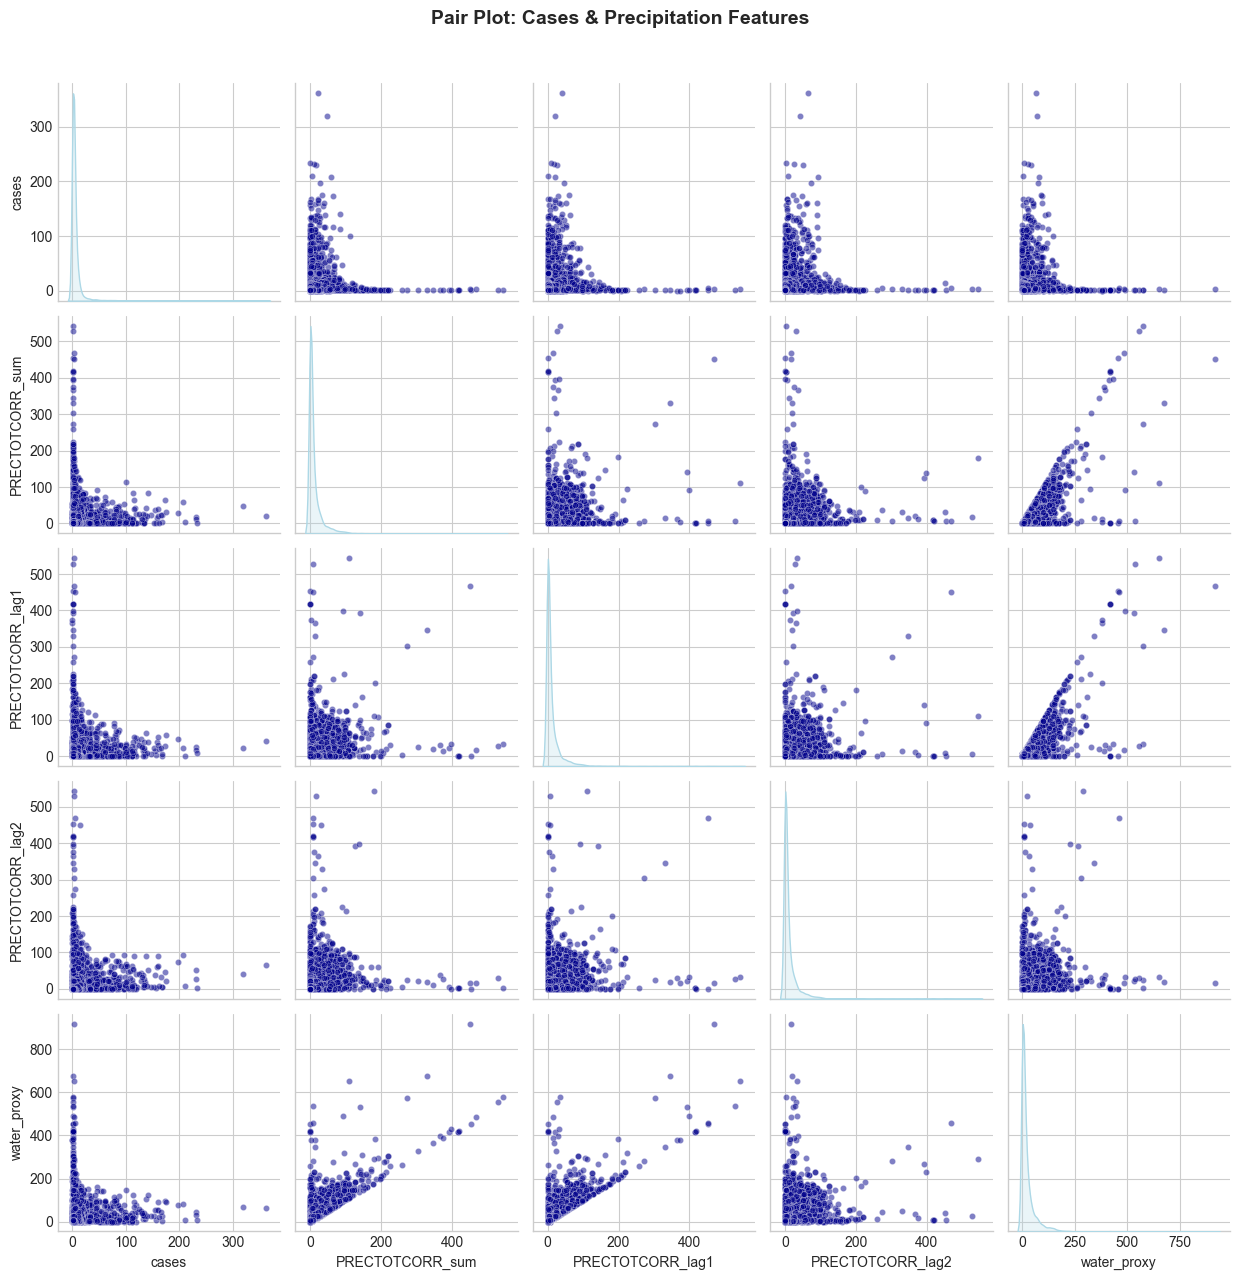

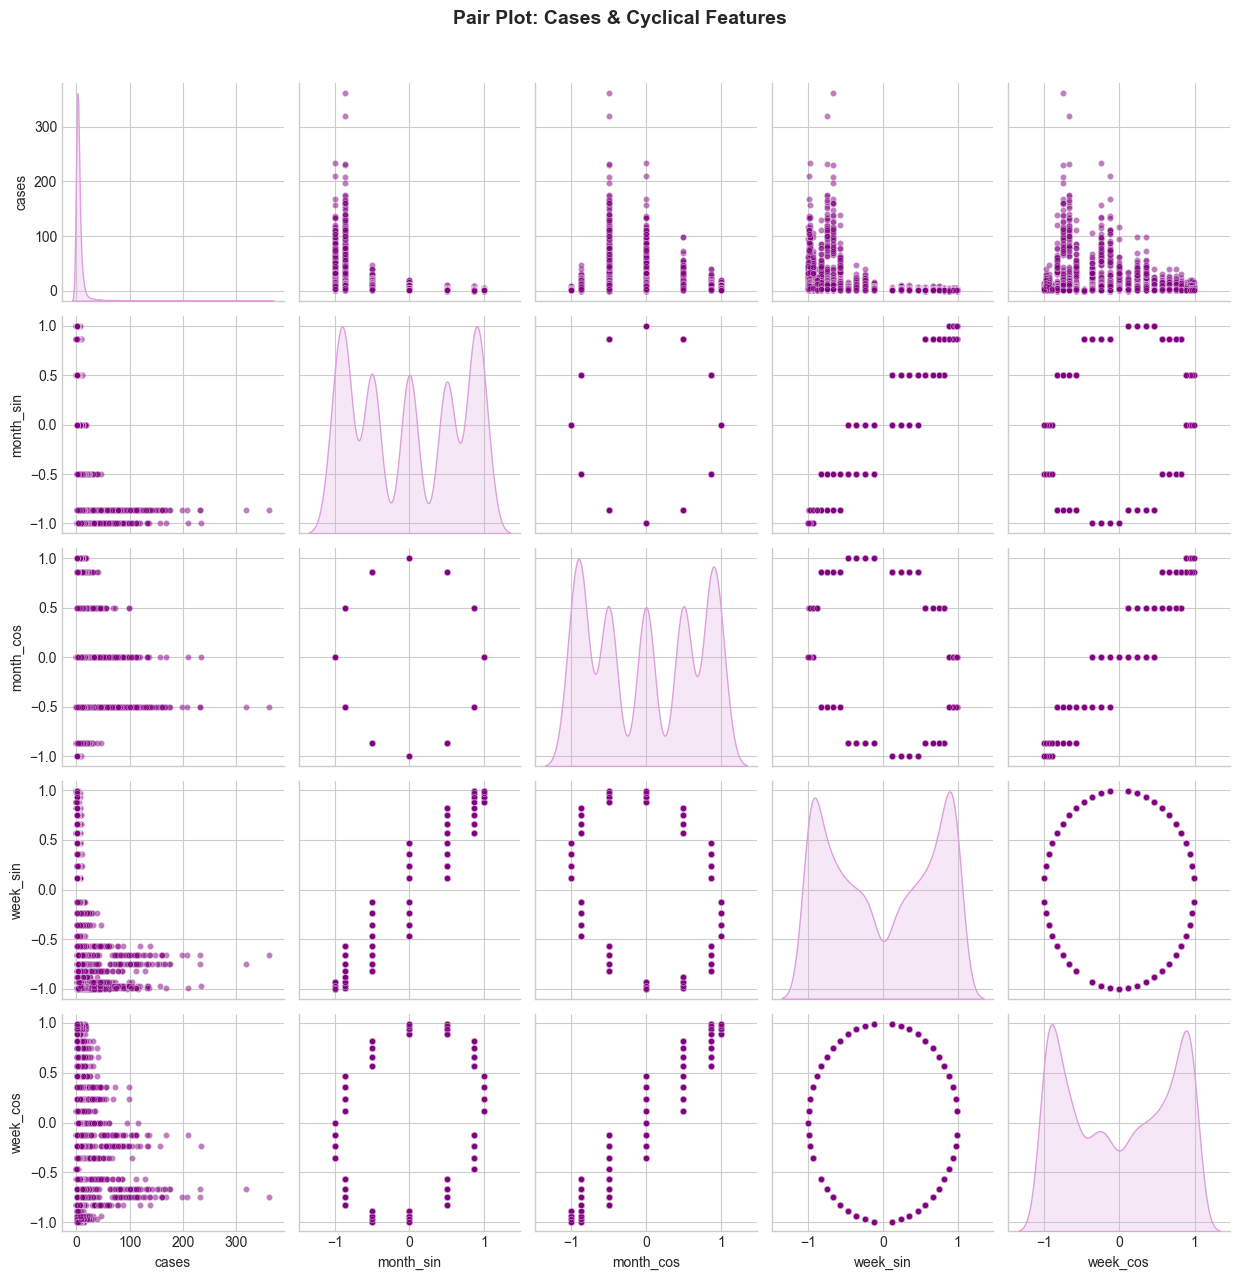

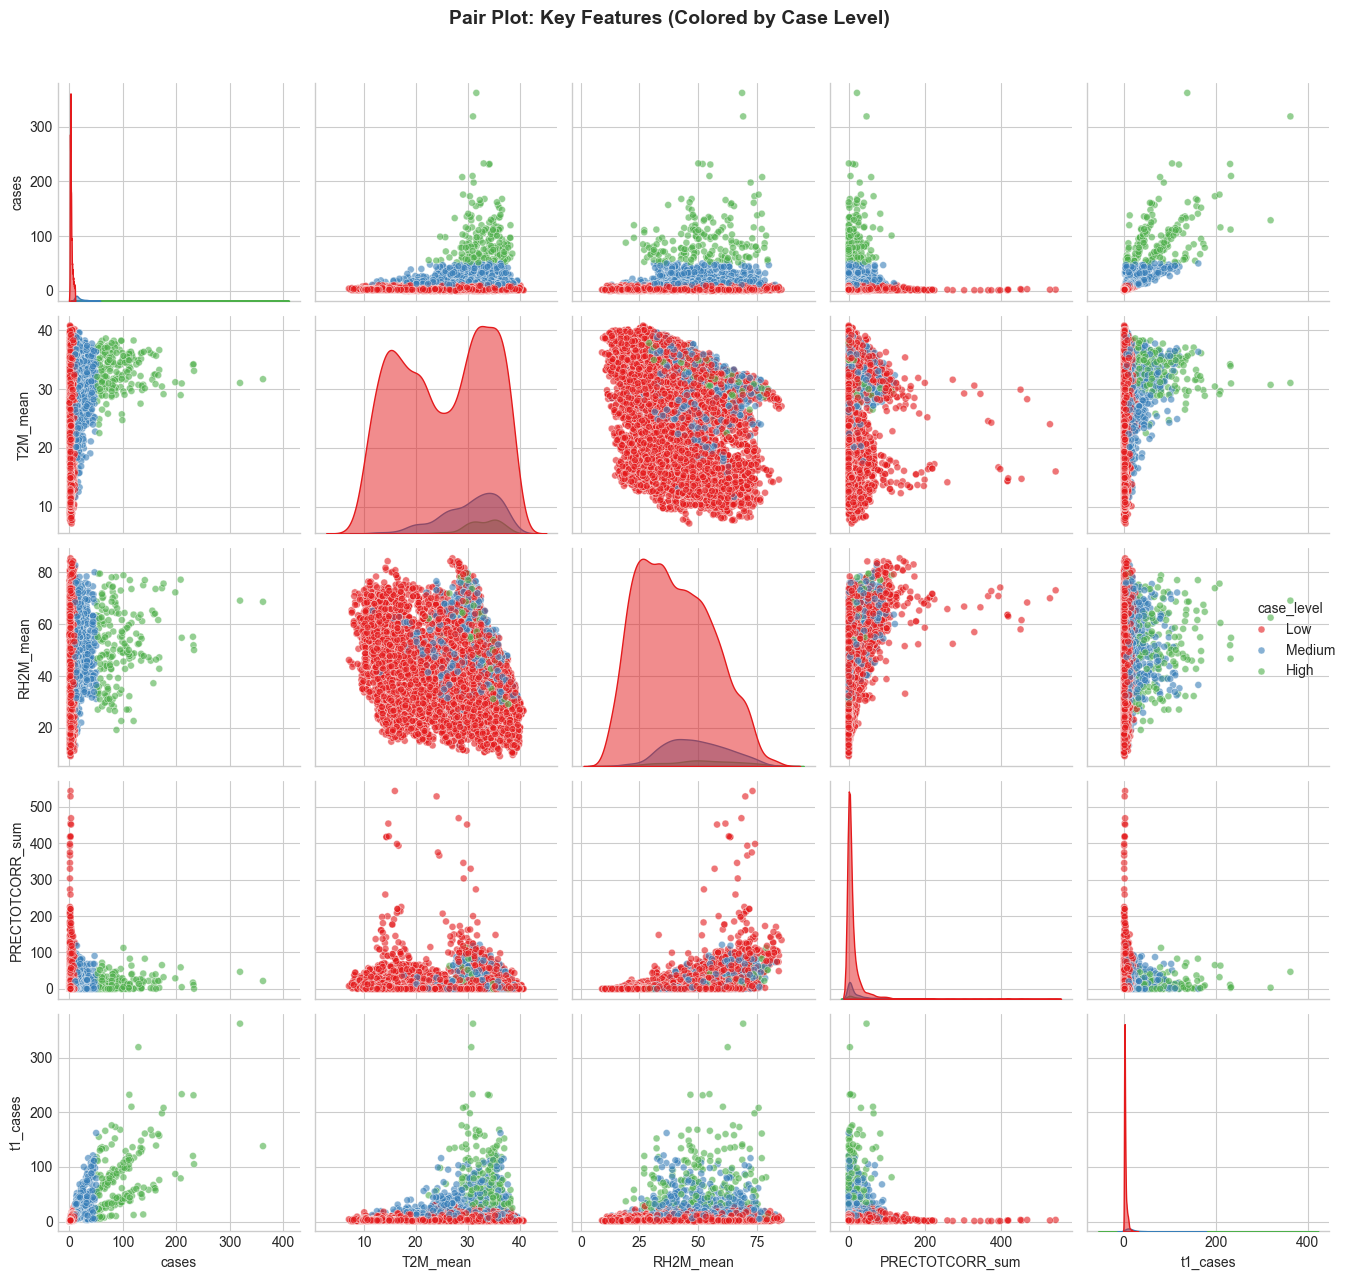

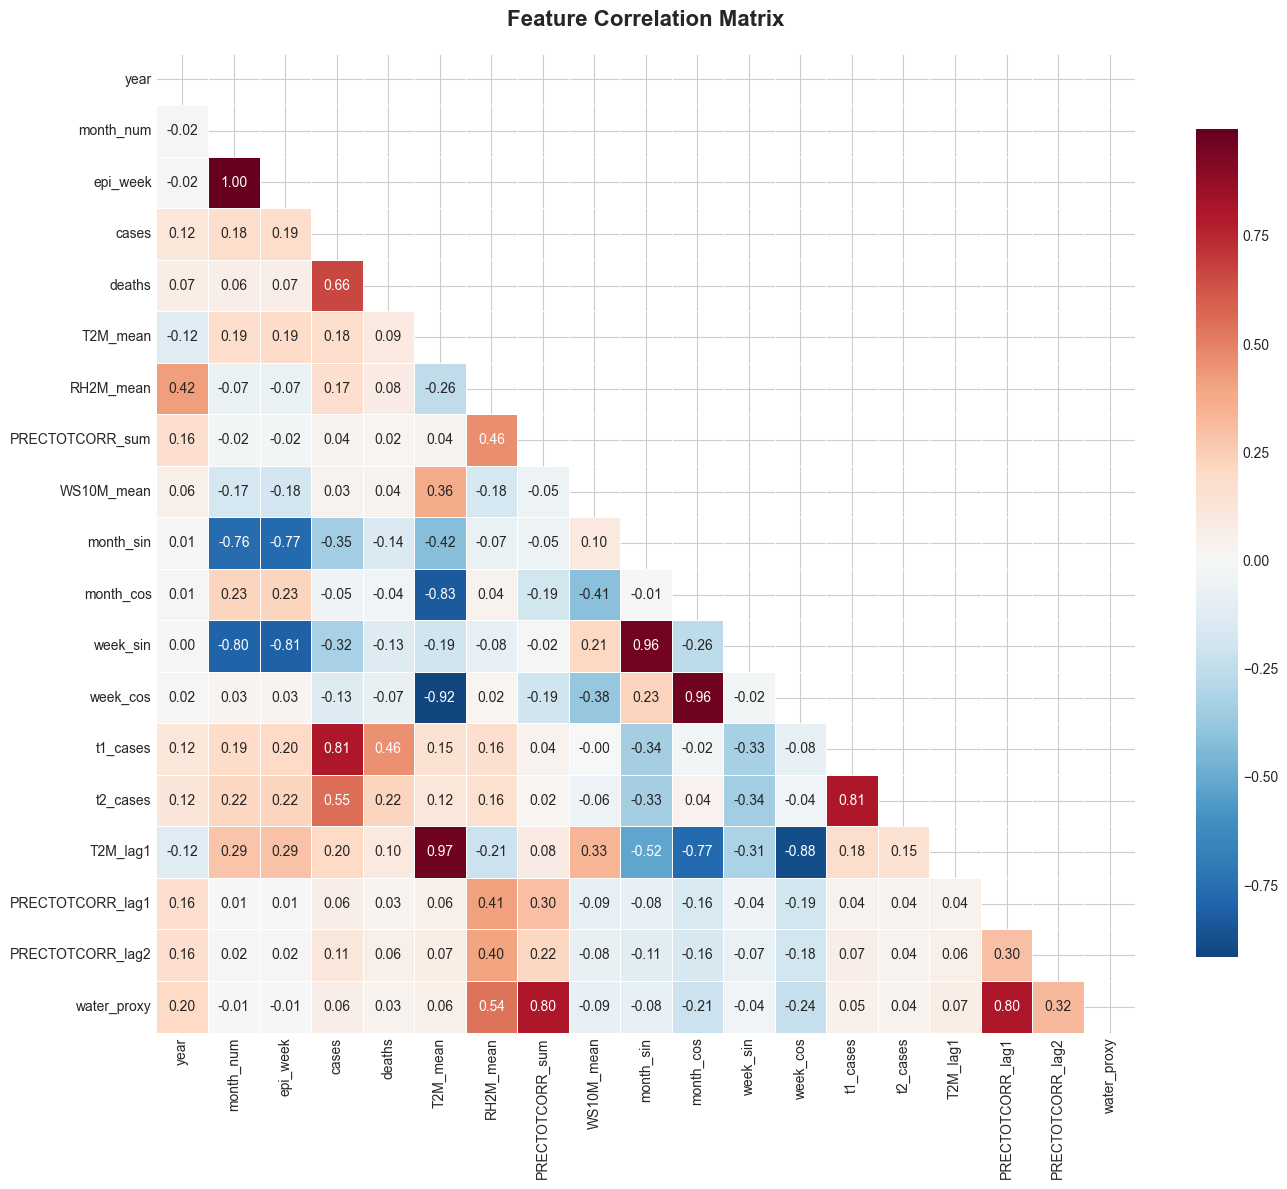

TOP CORRELATIONS WITH CASES (TARGET)
  ↑ t1_cases                 : +0.810  (Strong)
  ↑ deaths                   : +0.665  (Moderate)
  ↑ t2_cases                 : +0.552  (Moderate)
  ↓ month_sin                : -0.346  (Weak)
  ↓ week_sin                 : -0.320  (Weak)
  ↑ T2M_lag1                 : +0.198  (Weak)
  ↑ epi_week                 : +0.187  (Weak)
  ↑ month_num                : +0.184  (Weak)
  ↑ T2M_mean                 : +0.177  (Weak)
  ↑ RH2M_mean                : +0.166  (Weak)


In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
df = pd.read_csv('../data/processed/updated-Punjab.csv')

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

# ============================================================
# PAIR PLOT 1: TARGET + LAG FEATURES (Core temporal relationships)
# ============================================================

lag_features = ['cases', 't1_cases', 't2_cases', 'T2M_mean', 'T2M_lag1']
g1 = sns.pairplot(df[lag_features], 
                  diag_kind='kde',
                  plot_kws={'alpha': 0.5, 's': 20, 'color': 'steelblue'},
                  diag_kws={'fill': True, 'color': 'coral'})
g1.fig.suptitle('Pair Plot: Cases & Lag Features', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

# ============================================================
# PAIR PLOT 2: WEATHER FEATURES (Environmental drivers)
# ============================================================

weather_features = ['cases', 'T2M_mean', 'RH2M_mean', 'PRECTOTCORR_sum', 'WS10M_mean']
g2 = sns.pairplot(df[weather_features],
                  diag_kind='kde',
                  plot_kws={'alpha': 0.5, 's': 20, 'color': 'forestgreen'},
                  diag_kws={'fill': True, 'color': 'gold'})
g2.fig.suptitle('Pair Plot: Cases & Weather Features', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

# ============================================================
# PAIR PLOT 3: PRECIPITATION LAGS (Water-related features)
# ============================================================

precip_features = ['cases', 'PRECTOTCORR_sum', 'PRECTOTCORR_lag1', 'PRECTOTCORR_lag2', 'water_proxy']
g3 = sns.pairplot(df[precip_features],
                  diag_kind='kde',
                  plot_kws={'alpha': 0.5, 's': 20, 'color': 'darkblue'},
                  diag_kws={'fill': True, 'color': 'lightblue'})
g3.fig.suptitle('Pair Plot: Cases & Precipitation Features', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

# ============================================================
# PAIR PLOT 4: CYCLICAL FEATURES (Seasonal encoding)
# ============================================================

cyclical_features = ['cases', 'month_sin', 'month_cos', 'week_sin', 'week_cos']
g4 = sns.pairplot(df[cyclical_features],
                  diag_kind='kde',
                  plot_kws={'alpha': 0.5, 's': 20, 'color': 'purple'},
                  diag_kws={'fill': True, 'color': 'plum'})
g4.fig.suptitle('Pair Plot: Cases & Cyclical Features', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

# ============================================================
# PAIR PLOT 5: COMPACT ALL-IN-ONE (Key features only, hue by high/low cases)
# ============================================================

# Create binary flag for color coding
df['case_level'] = pd.cut(df['cases'], bins=[-1, 10, 50, 1000], labels=['Low', 'Medium', 'High'])

key_features = ['cases', 'T2M_mean', 'RH2M_mean', 'PRECTOTCORR_sum', 't1_cases']
g5 = sns.pairplot(df[key_features + ['case_level']], 
                  hue='case_level',
                  diag_kind='kde',
                  palette='Set1',
                  plot_kws={'alpha': 0.6, 's': 25},
                  diag_kws={'fill': True, 'alpha': 0.5})
g5.fig.suptitle('Pair Plot: Key Features (Colored by Case Level)', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()

plt.show()

# ============================================================
# CORRELATION HEATMAP (Complement to pair plots)
# ============================================================

plt.figure(figsize=(14, 12))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()

plt.show()

# ============================================================
# PRINT KEY CORRELATIONS WITH TARGET
# ============================================================

print("=" * 60)
print("TOP CORRELATIONS WITH CASES (TARGET)")
print("=" * 60)
target_corr = corr_matrix['cases'].drop('cases').sort_values(key=abs, ascending=False)
for feature, corr in target_corr.head(10).items():
    direction = "↑" if corr > 0 else "↓"
    strength = "Strong" if abs(corr) > 0.7 else "Moderate" if abs(corr) > 0.4 else "Weak"
    print(f"  {direction} {feature:25s}: {corr:+.3f}  ({strength})")